## Trabalho Computacional 3. Rede Convolucional e Transfer Learning

Ana Júlia Brant Lobato

200056832

## Introdução e base de dados

In [7]:
import torch
import torchvision
import torchvision.transforms as transforms

In [8]:
class CIFAR10():
    def __init__(self, root, resize=(224, 224)):
        trans = transforms.Compose([transforms.Resize(resize),
                                    transforms.ToTensor(),
                                    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
        self.train = torchvision.datasets.CIFAR10(
            root=root, train=True, transform=trans, download=True)
        # use 20% of training data for validation
        train_set_size = int(len(self.train) * 0.8)
        valid_set_size = len(self.train) - train_set_size
         # split the train set into two
        seed = torch.Generator().manual_seed(42)
        self.train, self.val = torch.utils.data.random_split(self.train, [train_set_size, valid_set_size], generator=seed)
        self.test = torchvision.datasets.CIFAR10(
            root=root, train=False, transform=trans, download=True)

dataset = CIFAR10(root="./data/")

train_dataloader = torch.utils.data.DataLoader(dataset.train, batch_size=64, shuffle=True, num_workers=4)
val_dataloader = torch.utils.data.DataLoader(dataset.val, batch_size=64, shuffle=False, num_workers=4)
test_dataloader = torch.utils.data.DataLoader(dataset.test, batch_size=64, shuffle=False, num_workers=4)

print(f"Number of training examples: {len(dataset.train)}")
print(f"Number of validation examples: {len(dataset.val)}")
print(f"Number of test examples: {len(dataset.test)}")

100%|██████████| 170M/170M [00:06<00:00, 27.7MB/s]


Number of training examples: 40000
Number of validation examples: 10000
Number of test examples: 10000


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


#### Amostras de imagens da base de dados com seus respectivos rótulos


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


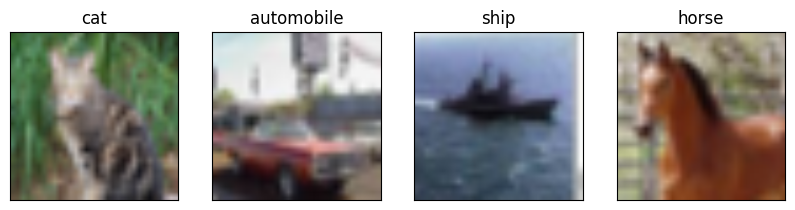

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

dataiter = iter(train_dataloader)
images, labels = next(dataiter)

def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    return np.transpose(npimg, (1, 2, 0))

fig = plt.figure(figsize=(10, 4))

for idx in range(4):
    ax = fig.add_subplot(1, 4, idx + 1, xticks=[], yticks=[])
    ax.imshow(imshow(images[idx]))
    ax.set_title(classes[labels[idx].item()])

plt.show()

## Treinamento do MLP

In [10]:
%pip install pytorch-lightning
import pytorch_lightning as pl
import torch.nn as nn
from torchmetrics.functional import accuracy

# The model is passed as an argument to the `LightModel` class.
class LightModel(pl.LightningModule):
	def __init__(self,model,lr=1e-5):
		super().__init__()
		self.model = model
		self.lr = lr
	def training_step(self, batch):
		X, y = batch
		y_hat = self.model(X)
		loss = nn.functional.cross_entropy(y_hat, y)
		self.log("train_loss", loss)
		return loss
	def validation_step(self, batch):
		X, y = batch
		y_hat = self.model(X)
		loss = nn.functional.cross_entropy(y_hat, y)
		self.log("val_loss", loss)
		return loss
	def test_step(self, batch):
		X, y = batch
		y_hat = self.model(X)
		preds = torch.argmax(y_hat, dim=1)
		acc = accuracy(preds, y, task="multiclass", num_classes=10)
		self.log("test_acc", acc)
		loss = nn.functional.cross_entropy(y_hat, y)
		self.log("test_loss", loss)
	def configure_optimizers(self):
		optimizer = torch.optim.Adam(self.parameters(), self.lr)
		return optimizer


arch = nn.Sequential(
			nn.Flatten(),
			nn.Linear(3*224*224,512),
			nn.ReLU(),
			nn.Linear(512,256),
			nn.ReLU(),
			nn.Linear(256,10)
	)

mlp = LightModel(arch)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 60.2 MB/s eta 0:00:00


In [ ]:
from pytorch_lightning.callbacks import EarlyStopping
from pytorch_lightning import Trainer

early_stopping = EarlyStopping(
    monitor='val_loss',  # metric to monitor
    patience=5,          # epochs with no improvement after which training will stop
    mode='min',          # mode for min loss; 'max' if maximizing metric
    min_delta=0.001      # minimum change to qualify as an improvement
)

trainer = Trainer(callbacks=[early_stopping], max_epochs=10)
trainer.fit(model=mlp, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ Sequential │ 77.2 M │ train │     0 │
└───┴───────┴────────────┴────────┴───────┴───────┘

Trainable params: 77.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 77.2 M                                                                                               
Total estimated model params size (MB): 308.819                                                                    
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will 
create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller 
than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader 
running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


In [ ]:
trainer.test(model=mlp, dataloaders=test_dataloader)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.5253999829292297     │
│         test_loss         │    1.3592087030410767     │
└───────────────────────────┴───────────────────────────┘

[{'test_acc': 0.5253999829292297, 'test_loss': 1.3592087030410767}]

Note que, para este modelo, ele apresenta uma acurácia de 52% e uma perda de teste de 1,36. Vamos ver a seguir um comparativo com a funçã VGG. Espera-se que a acurácia aumente e que a perda diminua.

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


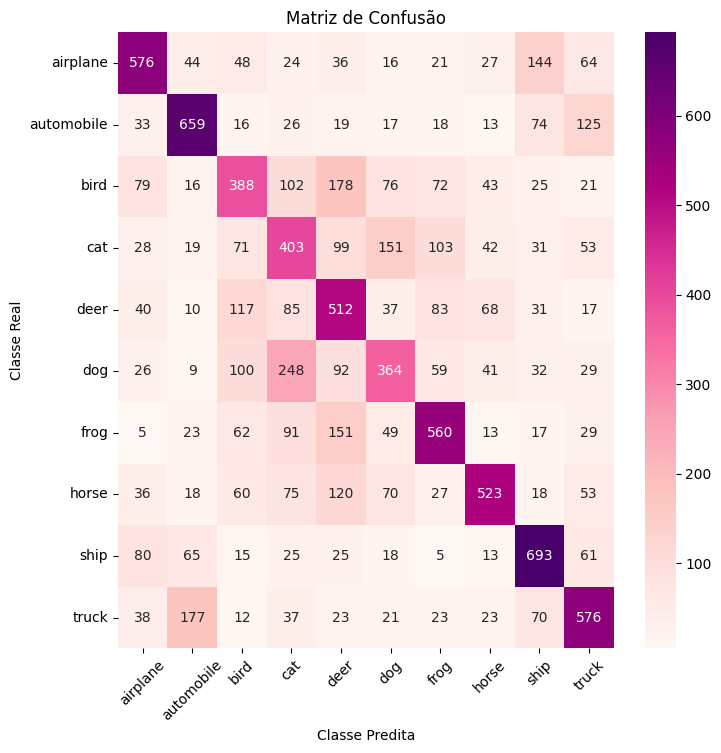

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


mlp.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for batch in test_dataloader:
        X, y = batch
        y_hat = mlp.model(X)
        preds = torch.argmax(y_hat, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y.cpu().numpy())


cm = confusion_matrix(all_targets, all_preds)


plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap=plt.cm.RdPu, xticklabels=classes, yticklabels=classes)
plt.title('Matriz de Confusão')
plt.xlabel('Classe Predita')
plt.ylabel('Classe Real')
plt.xticks(rotation=45)
plt.show()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


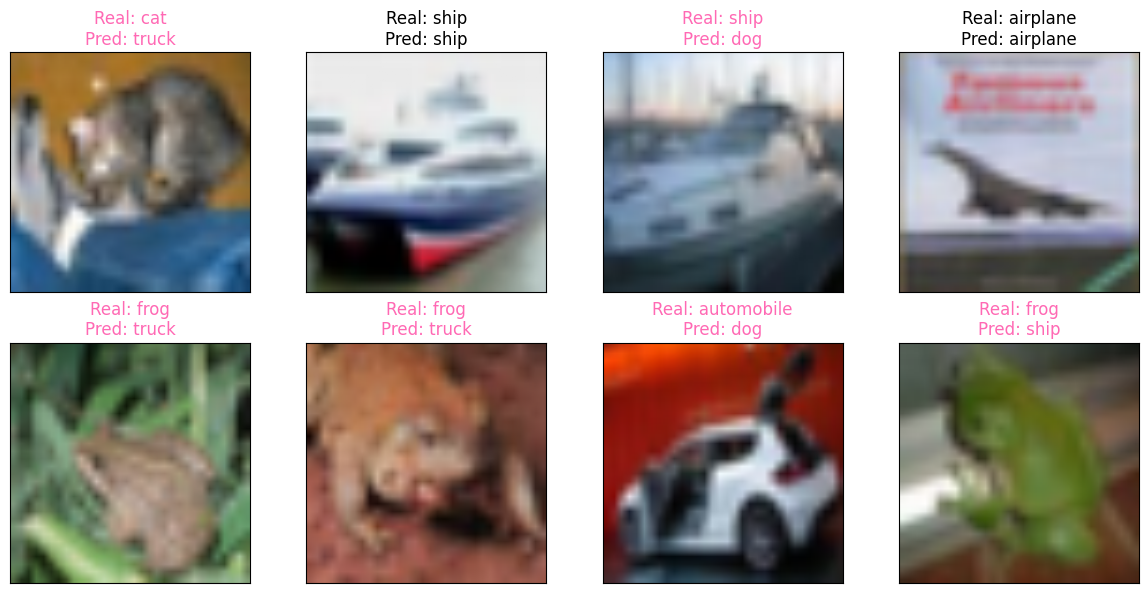

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import torch


classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


images, labels = next(iter(test_dataloader))


mlp.model.eval()
with torch.no_grad():

    outputs = mlp.model(images)
    preds = torch.argmax(outputs, dim=1)


fig = plt.figure(figsize=(12, 6))
for idx in range(8):  # Mostra as primeiras 8 imagens do lote
    ax = fig.add_subplot(2, 4, idx + 1, xticks=[], yticks=[])


    img = images[idx] / 2 + 0.5
    npimg = np.transpose(img.numpy(), (1, 2, 0))
    ax.imshow(npimg)

    true_label = classes[labels[idx].item()]
    pred_label = classes[preds[idx].item()]

    color = "black" if true_label == pred_label else "hotpink"

    ax.set_title(f"Real: {true_label}\nPred: {pred_label}", color=color)

plt.tight_layout()
plt.show()

## Rede VGG16 pré-treinada

In [17]:
from torchvision.models import vgg16
vgg16_model = vgg16(weights="DEFAULT", progress=True)

for param in vgg16_model.parameters():
	param.requires_grad = False

print(vgg16_model)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 86.6MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [18]:
vgg16_model.classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(512 * 7 * 7, 50),
    nn.ReLU(),
    nn.Linear(50, 20),
    nn.ReLU(),
    nn.Linear(20, 10)
)


vgg_lightning_model = LightModel(vgg16_model)

In [25]:
import pytorch_lightning as pl
import torch
import torch.nn as nn
from torchmetrics.functional import accuracy

class LightModelVGG(pl.LightningModule):
    def __init__(self, model, lr=1e-4):
        super().__init__()
        self.model = model
        self.lr = lr

    def training_step(self, batch):
        X, y = batch
        y_hat = self.model(X)
        loss = nn.functional.cross_entropy(y_hat, y)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch):
        X, y = batch
        y_hat = self.model(X)
        loss = nn.functional.cross_entropy(y_hat, y)
        self.log("val_loss", loss)
        return loss

    def test_step(self, batch):
        X, y = batch
        y_hat = self.model(X)
        preds = torch.argmax(y_hat, dim=1)
        acc = accuracy(preds, y, task="multiclass", num_classes=10)
        self.log("test_acc", acc)
        loss = nn.functional.cross_entropy(y_hat, y)
        self.log("test_loss", loss)

    def configure_optimizers(self):

        trainable_params = [p for p in self.parameters() if p.requires_grad]
        optimizer = torch.optim.Adam(trainable_params, self.lr)
        return optimizer

vgg_lightning_model = LightModelVGG(vgg16_model)

In [28]:
from pytorch_lightning.callbacks import EarlyStopping
from pytorch_lightning import Trainer


early_stopping_vgg = EarlyStopping(
    monitor='val_loss',
    patience=5,
    mode='min',
    min_delta=0.001
)


trainer_vgg = Trainer(
    callbacks=[early_stopping_vgg],
    max_epochs=5, #Não consegui rodar mais que 5 épocas no meu computador
    accelerator="auto"
)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [29]:
trainer_vgg.fit(
    model=vgg_lightning_model,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader
)

Epoch 4/4  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625/625 0:03:32 • 0:00:00 2.95it/s v_num: 1.000

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


In [32]:
trainer_vgg.test(model=vgg_lightning_model, dataloaders=test_dataloader)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.8521999716758728     │
│         test_loss         │    0.43614891171455383    │
└───────────────────────────┴───────────────────────────┘

[{'test_acc': 0.8521999716758728, 'test_loss': 0.43614891171455383}]

Conforme esperado, a acurácia aumentou para cerca de 85% e a perda de teste diminuiu para 0,43, demonstrando que as camadas convolucionais do VGG permitem que o modelo "entenda" melhor as imagens antes de classificá-las.

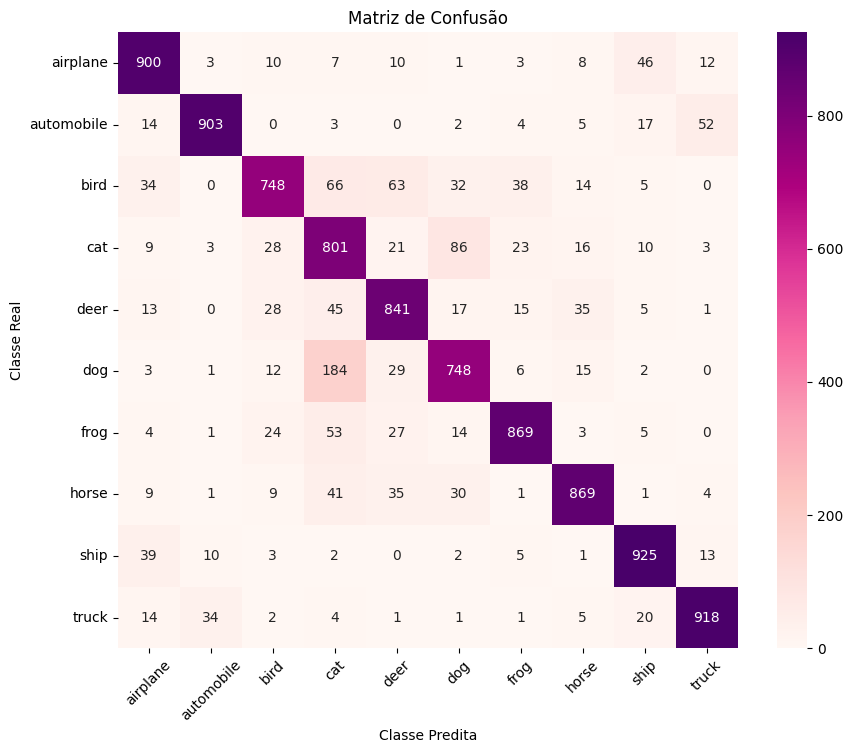

In [30]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import torch
import matplotlib.pyplot as plt

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


vgg_lightning_model.model.eval()
vgg_lightning_model.model.to(device)

all_preds = []
all_targets = []


with torch.no_grad():
    for batch in test_dataloader:
        X, y = batch


        X = X.to(device)


        y_hat = vgg_lightning_model.model(X)

        preds = torch.argmax(y_hat, dim=1)


        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y.numpy())

cm_vgg = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(10, 8))

sns.heatmap(cm_vgg, annot=True, fmt='d', cmap=plt.cm.RdPu, xticklabels=classes, yticklabels=classes)
plt.title('Matriz de Confusão')
plt.xlabel('Classe Predita')
plt.ylabel('Classe Real')
plt.xticks(rotation=45)
plt.show()

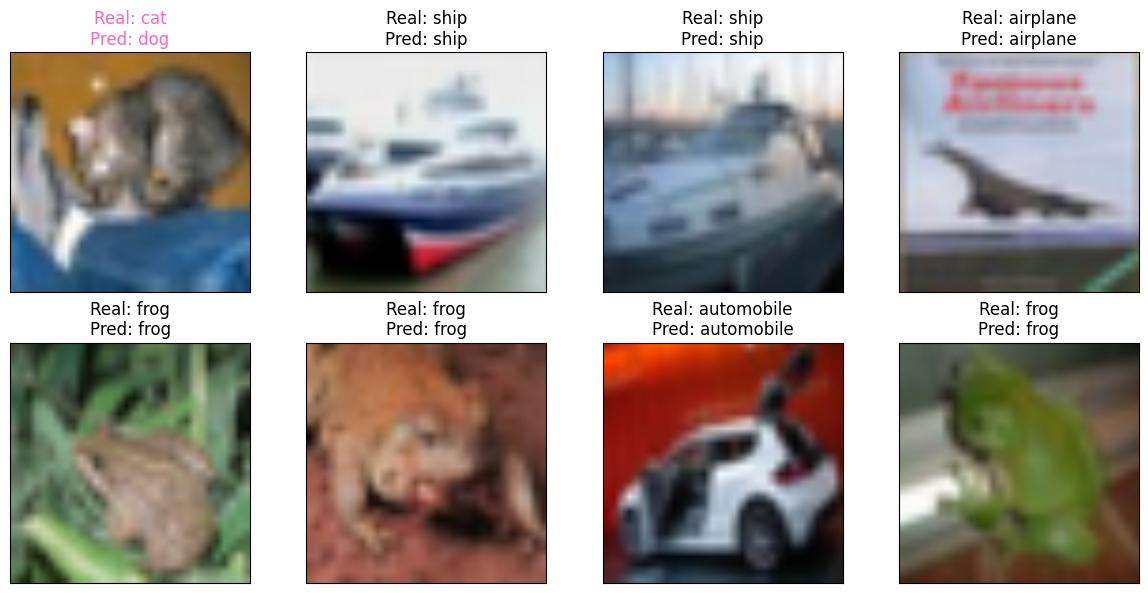

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import torch


classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


images, labels = next(iter(test_dataloader))


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vgg_lightning_model.model.eval()
vgg_lightning_model.model.to(device)

with torch.no_grad():

    outputs = vgg_lightning_model.model(images.to(device))
    preds = torch.argmax(outputs, dim=1)

fig = plt.figure(figsize=(12, 6))
for idx in range(8):  # Mostra as primeiras 8 imagens do lote
    ax = fig.add_subplot(2, 4, idx + 1, xticks=[], yticks=[])


    img = images[idx] / 2 + 0.5
    npimg = np.transpose(img.numpy(), (1, 2, 0))
    ax.imshow(npimg)

    true_label = classes[labels[idx].item()]
    pred_label = classes[preds[idx].item()]

    color = "black" if true_label == pred_label else "hotpink"

    ax.set_title(f"Real: {true_label}\nPred: {pred_label}", color=color)

plt.tight_layout()
plt.show()